In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, random, torch
import torch.nn as nn
from tqdm import tqdm
from pathlib import PureWindowsPath
from monai.transforms import LoadImage
from monai.data import Dataset, DataLoader
from monai.transforms import (Compose,LoadImaged,ScaleIntensityd, ScaleIntensityRanged, Resized)
from monai.networks.nets import resnet10
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch.nn.functional as F
from monai.data import MetaTensor

import sys
sys.path.append("/projects/net_contrast_classification/contrast_phase")

from Radiomics.models_pipe import train_tree_models
from Radiomics.data_preprocessing import radiomics_load, train_test_split, preprocess_train, preprocess_test
import segmentation_models_pytorch as smp

In [10]:
data_dir = Path("/projects/net_contrast_classification/contrast_phase/data/cleaned_data_1.csv")

features_dir = Path("/projects/net_contrast_classification/contrast_phase/Radiomics/features")

radiomics = radiomics_load(data_dir, features_dir)

train_data, test_data = train_test_split(radiomics, test_size=0.3, grouping="SubjectKeyRadiology")

meta_cols = list(train_data.iloc[:, :5].columns)

train_pipeline = preprocess_train(train_data, meta_cols,NA_filter_threshold=0.2, pca_components=30)

train_processed = train_pipeline["data_processed"]
X_train_pca = train_pipeline["X_pca"]
test_processed, X_test_pca = preprocess_test(test_data, meta_cols,train_pipeline)

contrast_le = LabelEncoder()

X_train, y_train = train_processed.iloc[:, 4:], contrast_le.fit_transform(train_processed.contrast)
X_test, y_test = test_processed.iloc[:, 4:], contrast_le.fit_transform(test_processed.contrast)

print(f"Shape of train data: {X_train.shape}\nShape of train labels: {y_train.shape}")
print(f"Shape of test data: {X_test.shape}\nShape of test labels: {y_test.shape}")

models = train_tree_models(X_train, y_train)

Shape of train data: (5672, 212)
Shape of train labels: (5672,)
Shape of test data: (2661, 212)
Shape of test labels: (2661,)


In [11]:
GBT_model = models['GBT']

In [ ]:

def data_load(dataset, sample = None):
    dataset['server_folder'] = dataset.exist_on_server.apply(lambda x: "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET" 
                                                             if pd.notna(x)  
                                                             else "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server")
    
    dataset = dataset[(dataset.contrast.isin(['Arterial', "Portal"]))
                & (dataset.is_liver_imaged == "Yes")
                & (dataset.phase_timing != '0.0')
                & (dataset.is_lesionfree == "No") # remove later
                ]
    
    dataset = dataset.sort_values(by=["SubjectKeyRadiology", "ExamDate", "contrast"], ascending=True)


    if not sample:
        files = [os.path.join(row['server_folder'], PureWindowsPath(row['MatchKey']).name) for _, row in dataset.iterrows()]
        organ_files = [f.replace(".nii.gz", ".organs.nii.gz") for f in files]
        seg_files = [f.replace(".nii.gz", ".seg.nii.gz") for f in files]
        labels = list(dataset.contrast)

    else:
        dataset['contrast_timing'] = (dataset["contrast"].str.cat(dataset["phase_timing"], sep=" "))
        dataset["contrast_timing"] = dataset["contrast_timing"].astype(str).str.strip()

        sampled_df = dataset.groupby('contrast_timing', group_keys=False).apply(lambda x: x.sample(n=min(len(x), sample), random_state=42))

        files = [os.path.join(row['server_folder'], PureWindowsPath(row['MatchKey']).name) for _, row in sampled_df.iterrows()]
        organ_files = [f.replace(".nii.gz", ".organs.nii.gz") for f in files]
        seg_files = [f.replace(".nii.gz", ".seg.nii.gz") for f in files]
        labels = list(sampled_df.contrast)



    return files, organ_files, seg_files, labels

In [21]:
data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/data/cleaned_data_1.csv")
data.is_lesionfree

0        No
1        No
2       Yes
3       Yes
4        No
       ... 
8729     No
8730    Yes
8731     No
8732    Yes
8733    Yes
Name: is_lesionfree, Length: 8734, dtype: str

In [ ]:
data.iloc[8723:8725, :]

,NiiFile,SegNiiFile,Original File,Destination Folder,New File,SubjectKeyRadiology,ExamDate,file,is_liver_imaged,contrast,...,ConversionSoftware,ConversionSoftwareVersion,BodyPartExamined,RawImage,SliceThickness,AcquisitionTime_sec,DICOM_phase,MatchKey,exist_on_server,server_folder
8723,Z:\_archived\DICOM-batch3-kalina99\NET_5821_00...,Z:\_archived\DICOM-batch3-kalina99\NET_5821_00...,../DICOM-batch3\NKI-d23231-00-0887\20230830 CT...,DICOM-batch3-kalina99,NET_5821_0000.nii.gz,NKI-d23231-00-0887,2023-08-30,NET_5821_0000.nii.gz,Yes,Arterial,...,dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,47716.7,Arterial,NKI-d23231-00-0887_20230830_kalina99_5821.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET
8724,Z:\_archived\DICOM-batch3-kalina99\NET_5822_00...,Z:\_archived\DICOM-batch3-kalina99\NET_5822_00...,../DICOM-batch3\NKI-d23231-00-0887\20230830 CT...,DICOM-batch3-kalina99,NET_5822_0000.nii.gz,NKI-d23231-00-0887,2023-08-30,NET_5822_0000.nii.gz,Yes,Portal,...,dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,47745.6,Portal,NKI-d23231-00-0887_20230830_kalina99_5822.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...,/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET


In [ ]:
files, organ_files, seg_files, labels = data_load(data.iloc[8723:8725, :])

In [ ]:
print(labels[0], files[0], organ_files[0], seg_files[0])
print(labels[1], files[1], organ_files[1], seg_files[1])

Arterial /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0887_20230830_kalina99_5821.nii.gz /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0887_20230830_kalina99_5821.seg.nii.gz
Portal /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0887_20230830_kalina99_5822.nii.gz /mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0887_20230830_kalina99_5822.seg.nii.gz


In [ ]:
def window_ct(img, center=50, width=150):
    low = center - width / 2
    high = center + width / 2
    return img.clip(low, high)

loader = LoadImage(image_only=True, ensure_channel_first=True)
image_a = loader(files[0])
seg_a = loader(seg_files[0])

image_p = loader(files[1])
seg_p = loader(seg_files[1])

[115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132
 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150
 151 152 153 154 155 156 157 158 159 160 161 162]


/tmp/ipykernel_784110/567553338.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  rgba_a[..., 3] = mask_a * 0.5


[114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131
 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149
 150 151 152 153 154 155 156 157 158 159 160 161 162]


/tmp/ipykernel_784110/567553338.py:36: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  rgba_p[..., 3] = mask_p * 0.5


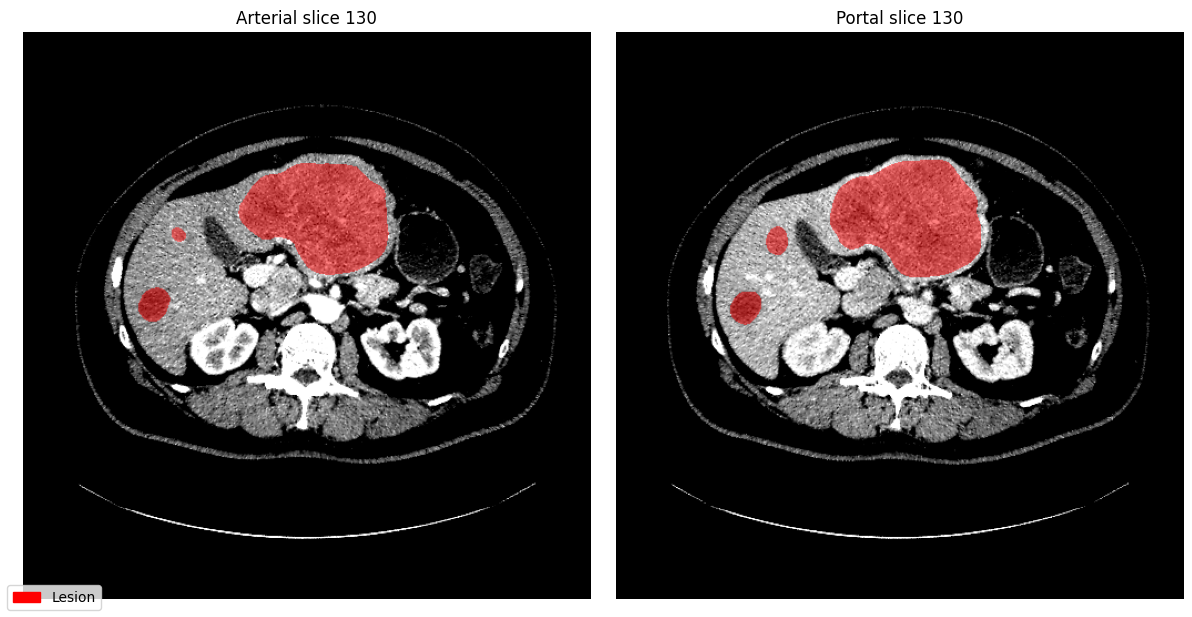

In [ ]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# -------------------------
# Arterial slice
# -------------------------
lesion_slices_a = np.where(seg_a[0].sum(axis=(0, 1)) > 0)[0]
print(lesion_slices_a)
slice_idx_a = lesion_slices_a[len(lesion_slices_a)//2]
slice_idx_a = 130
ct_slice_a = np.rot90(image_a[0, :, :, slice_idx_a], k=1)
mask_a = seg_a[0, :, :, slice_idx_a] > 0

axes[0].imshow(window_ct(ct_slice_a), cmap="gray")
rgba_a = np.zeros((*mask_a.shape, 4))
rgba_a[..., :3] = [1, 0, 0]
rgba_a[..., 3] = mask_a * 0.5
axes[0].imshow(np.rot90(rgba_a, k=1))
axes[0].set_title(f"{str.capitalize(labels[0])} slice {slice_idx_a}")
axes[0].axis("off")

# -------------------------
# Portal slice
# -------------------------
lesion_slices_p = np.where(seg_p[0].sum(axis=(0, 1)) > 0)[0]
print(lesion_slices_p)
slice_idx_p = lesion_slices_p[len(lesion_slices_p)//2]
slice_idx_p = 130
ct_slice_p = np.rot90(image_p[0, :, :, slice_idx_p], k=1)
mask_p = seg_p[0, :, :, slice_idx_p] > 0

axes[1].imshow(window_ct(ct_slice_p), cmap="gray")
rgba_p = np.zeros((*mask_p.shape, 4))
rgba_p[..., :3] = [1, 0, 0]
rgba_p[..., 3] = mask_p * 0.5
axes[1].imshow(np.rot90(rgba_p, k=1))
axes[1].set_title(f"{str.capitalize(labels[1])} slice {slice_idx_p}")
axes[1].axis("off")

# -------------------------
# Legend (shared)
# -------------------------
legend_patches = [Patch(color="red", label="Lesion")]
fig.legend(handles=legend_patches, loc="lower left", framealpha=0.8, fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:

from Time_estim.time_estim import multi_channel, keep_organ_volume, get_2p5d_slices

class CTDataset(Dataset):
    def __init__(self, image_files, organ_files, seg_files, labels,
                 organ_ids, mode="3d", num_slices=None, transform=None):
        
        self.image_files = image_files
        self.organ_files = organ_files
        self.seg_files = seg_files
        self.labels = labels
        self.organ_ids = organ_ids
        self.mode = mode
        self.num_slices = num_slices
        self.transform = transform  # MONAI transforms

        self.loader = LoadImage(image_only=True, ensure_channel_first=True)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # -------- Load image --------
        image_array = self.loader(self.image_files[idx])
        organ_array = self.loader(self.organ_files[idx])
        seg_array = self.loader(self.seg_files[idx])
        label = self.labels[idx]

        organ_array = None
        volume = image_array  # default fallback

        # -------- Try organ processing --------
        try:
            organ_array_single = self.loader(self.organ_files[idx])

            # check empty explicitly (better than relying on exception)
            if np.size(organ_array_single) == 0:
                raise ValueError("Empty organ file")

            organ_array = multi_channel(self.organ_ids, organ_array_single)

            # crop ONLY if valid
            volume = keep_organ_volume(image_array, organ_array)

        except Exception as e:
            print(f"Fallback to full volume for {self.organ_files[idx]}: {e}")

        # -------- Mode handling --------
        if self.mode == "3d":
            x = volume

        elif self.mode == "2p5d":
            x = get_2p5d_slices(
                volume=volume,
                organ_array=organ_array,  # None if failed → handled inside
                num_slices=self.num_slices
            )

        else:
            raise ValueError(f"Unknown mode: {self.mode}")

        # -------- Transforms --------
        if self.transform is not None:
            sample = {"image": x}
            sample = self.transform(sample)
            x = sample["image"]

        if not isinstance(x, MetaTensor):
            x = MetaTensor(x)

        y = seg_array
        if not isinstance(y, MetaTensor):
            y = MetaTensor(y)
        
        z = torch.tensor(label, dtype=torch.long)

        return {"image": x, "mask": y, "label":z}
    


In [ ]:
from monai.losses import DiceLoss
from monai.metrics import DiceMetric


def train_seg(model, train_loader, val_loader=None, epochs=10, lr=1e-4, weight_decay=1e-4):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    bce_loss = torch.nn.BCEWithLogitsLoss()                                                     # binary loss for each pixel (lesion or not) => converts logits to probabilities using sigmoid; stabilizes learning 
    dice_loss = DiceLoss(sigmoid=True)                                                          # overlap loss (1-dice overlap); sigmoid=True => converts logits to probabilities; improves the segmentation quality

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_loss = float("inf")
    patience = 3
    counter = 0
    best_model_state = None

    for epoch in range(epochs):
        # ------------------ TRAIN ------------------
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        dice_metric_train = DiceMetric(include_background=False, reduction="mean")
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)


        for batch in loop:
            images = batch["image"].to(device)
            masks = batch["mask"].to(device).float()

            optimizer.zero_grad()
            outputs = model(images)                                      # output = logits, e.g., +3.2 → strong confidence lesion; -2.1 → strong confidence background; 0.0 → uncertain

            loss = dice_loss(outputs, masks) + bce_loss(outputs, masks)  # combine both losses because class imbalance is high for segmentation (areas without lesions >> areas with lesions)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            loop.set_postfix(loss=loss.item())

            preds = torch.sigmoid(outputs)                               # logits -> probabilities
            preds = (preds > 0.5).float()                                # probabilities -> binary segmentation mask

            train_correct += (preds == masks).sum().item()               # counts how many pixels are correctly predicted and accumulates this number for each batch
            train_total += masks.numel()                                 # accumulates the total number of pixels in the ground truth masks for each batch

            with torch.no_grad():  
                dice_metric_train(preds, masks)                          # accumulates results internally            


        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = train_correct/ train_total                       # pixel-wise accuracy (not segmentation!)
        train_dice = dice_metric_train.aggregate().item()                # mean dice over all batches - segmentation quality
        dice_metric_train.reset()                                        # reset for the next epoch


        # ---------------- VALIDATION ----------------
        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            dice_metric = DiceMetric(include_background=False, reduction="mean")

            with torch.no_grad():
                for batch in val_loader:
                    images = batch["image"].to(device)
                    masks = batch["mask"].to(device).float()

                    outputs = model(images)
                    loss = dice_loss(outputs, masks) + bce_loss(outputs, masks)
                    val_loss += loss.item()

                    # Dice score for validation
                    preds = torch.sigmoid(outputs)                               # logits -> probabilities
                    preds = (preds > 0.5).float()                                # probabilities -> binary segmentation mask

                    val_correct += (preds == masks).sum().item()               # counts how many pixels are correctly predicted and accumulates this number for each batch
                    val_total += masks.numel()                                 # accumulates the total number of pixels in the ground truth masks for each batch
                    dice_metric(preds, masks)                                  # accumulates results internally 

            avg_val_loss = val_loss / len(val_loader)
            avg_val_acc = val_correct / val_total               # pixel-wise accuracy
            val_dice = dice_metric.aggregate().item()           # mean dice over all batches - segmentation quality
            dice_metric.reset()                                 # reset for the next epoch

            print(
                f"Epoch {epoch+1}: "
                f"train_loss={avg_train_loss:.4f}, train_pixel_acc={avg_train_acc:.4f} , train_dice={train_dice:.4f} | "
                f"val_loss={avg_val_loss:.4f}, val_pixel_acc={avg_val_acc:.4f}, val_dice={val_dice:.4f}",
                flush=True
            )

            # Early stopping
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                counter = 0
                best_model_state = model.state_dict()
                print("New best model")
            else:
                counter += 1
                print(f"No improvement ({counter}/{patience})")
                if counter >= patience:
                    print("Early stopping triggered")
                    break

    # Load best model weights
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model

In [ ]:
data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/data/cleaned_data_1.csv")

files, organ_files, seg_files, labels_raw = data_load(data)

le = LabelEncoder()
labels = le.fit_transform(labels_raw)

mode = "3d"
# num_slices = 7


temp_idx, test_idx = train_test_split(
    np.arange(len(files)),
    test_size=0.2,        # 20% test
    random_state=42,      # for reproducibility
    stratify=labels       # maintain class balance
)

train_idx, val_idx = train_test_split(
    temp_idx,
    test_size=0.2,
    random_state=42,
    stratify=labels[temp_idx]
)

transforms_3d = Compose([ScaleIntensityRanged(keys=["image"],a_min=-1000, a_max=1000,
                                            b_min=0.0, b_max=1.0,clip=True), 
                        Resized(keys=["image"], spatial_size=(64,64,64))])

transforms_2d = Compose([ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000,
                                            b_min=0.0, b_max=1.0, clip=True),
                        Resized(keys=["image"], spatial_size=(96, 96))])


# --------------------------------------------------- Train ---------------------------------------------------
# -------------------------------------------------------------------------------------------------------------

if mode == "3d":
    transforms, batches = transforms_3d, 1
    
else:
    transforms, batches = transforms_2d, 32

# Train dataset and dataloader
train_dataset = CTDataset(
                        image_files = [files[i] for i in train_idx],
                        organ_files = [organ_files[i] for i in train_idx],
                        seg_files = [seg_files[i] for i in train_idx],
                        labels = labels[train_idx],
                        organ_ids=[5],                          # take only liver - we want to segment only the liver metastases => saves memory
                        transform=transforms
                    )

train_loader = DataLoader(
    train_dataset,
    batch_size=batches,
    shuffle=False,
    num_workers=8,
    pin_memory=False
)

val_dataset = CTDataset(
                        image_files = [files[i] for i in val_idx],
                        organ_files = [organ_files[i] for i in val_idx],
                        seg_files = [seg_files[i] for i in val_idx],
                        labels = labels[val_idx],
                        organ_ids=[5],                          # take only liver - we want to segment only the liver metastases => saves memory
                        transform=transforms
                    )

val_loader = DataLoader(
                        val_dataset,
                        batch_size=batches,
                        shuffle=False,
                        num_workers=8,
                        pin_memory=False
                    )

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1
)

trained_model = train_seg(model, train_loader, weights = None, val_loader=val_loader)